In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(r"C:\Users\Lenovo\Desktop\Data Science Training\ML\unsupervised_ML\project\Nutrition recommendation system\Data\Food_Nutrition_Dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
# ==========================================
# Display First & Last Rows
# ==========================================

df.head()

,food_name,category,calories,protein,carbs,fat,iron,vitamin_c
0,"Apple, candied",Apples,134.0,1.34,29.61,2.15,0.12,3.6
1,"Apple, raw",Apples,61.0,0.17,14.80,0.15,0.03,4.6
2,"Apple, dried",Dried fruits,243.0,0.93,65.89,0.32,1.40,3.9
3,"Crisp, apple",Cakes and pies,215.0,2.81,30.18,9.59,1.00,0.6
4,"Apple, baked",Apples,113.0,0.32,22.70,3.08,0.19,3.9


In [5]:
# ==========================================
# Basic Information
# ==========================================

print("Shape :", df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
df.info()

Shape : (205, 8)

Columns
Index(['food_name', 'category', 'calories', 'protein', 'carbs', 'fat', 'iron',
       'vitamin_c'],
      dtype='str')

Information
<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   food_name  205 non-null    str    
 1   category   205 non-null    str    
 2   calories   205 non-null    float64
 3   protein    205 non-null    float64
 4   carbs      205 non-null    float64
 5   fat        205 non-null    float64
 6   iron       203 non-null    float64
 7   vitamin_c  202 non-null    float64
dtypes: float64(6), str(2)
memory usage: 12.9 KB


In [6]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe()

,calories,protein,carbs,fat,iron,vitamin_c
count,205.000000,205.000000,205.000000,205.000000,203.000000,202.000000
mean,243.790244,2.852829,25.573366,6.018000,0.851330,13.694554
std,283.580451,3.357243,20.119102,9.694549,1.103369,18.503094
min,16.000000,0.000000,1.790000,0.000000,0.000000,0.000000
25%,62.000000,0.640000,11.200000,0.200000,0.205000,1.625000
50%,166.000000,1.710000,17.220000,1.180000,0.410000,7.450000
75%,296.000000,3.200000,37.550000,9.390000,1.080000,17.375000
max,1460.000000,17.800000,85.130000,74.020000,9.090000,136.000000


In [7]:
# ==========================================
# Check Missing Values
# ==========================================

df.isnull().sum()

food_name    0
category     0
calories     0
protein      0
carbs        0
fat          0
iron         2
vitamin_c    3
dtype: int64

In [8]:
# ==========================================
# Check Duplicate Values
# ==========================================

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
# ==========================================
# Remove Duplicate Records
# ==========================================

df = df.drop_duplicates()

print("Duplicates Removed Successfully")

Duplicates Removed Successfully


In [10]:
# ==========================================
# Unique Food Categories
# ==========================================

df["category"].value_counts()

category
Fruits and Fruit Juices              23
Vegetables and Vegetable Products    17
Cakes and pies                       12
Yeast breads                         11
Beverages                             8
                                     ..
Restaurant Foods                      1
Vegetables on a sandwich              1
Rolls and buns                        1
Seafood mixed dishes                  1
Pork Products                         1
Name: count, Length: 61, dtype: int64

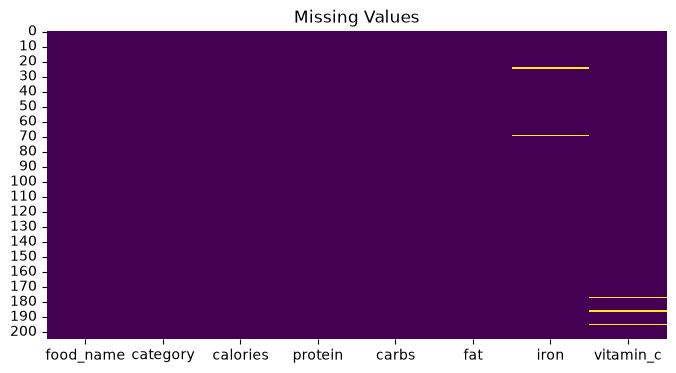

In [11]:
# ==========================================
# Missing Value Heatmap
# ==========================================

plt.figure(figsize=(8,4))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values")
plt.show()

In [12]:
# ==========================================
# Fill Missing Numerical Values
# ==========================================

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Missing Values Filled")

Missing Values Filled


In [13]:
# ==========================================
# Select Numerical Features
# ==========================================

X = df.drop(columns=["food_name","category"])

X.head()

,calories,protein,carbs,fat,iron,vitamin_c
0,134.0,1.34,29.61,2.15,0.12,3.6
1,61.0,0.17,14.80,0.15,0.03,4.6
2,243.0,0.93,65.89,0.32,1.40,3.9
3,215.0,2.81,30.18,9.59,1.00,0.6
4,113.0,0.32,22.70,3.08,0.19,3.9


In [14]:
# ==========================================
# Standardize Features
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling Completed")

Scaling Completed


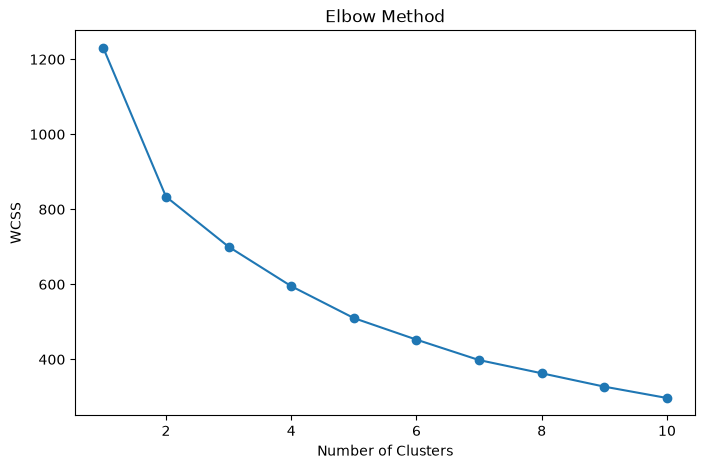

In [15]:
# ==========================================
# Elbow Method
# ==========================================

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [16]:
# ==========================================
# Silhouette Scores
# ==========================================

scores = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled,labels)

    scores.append(score)

for i,score in enumerate(scores,start=2):
    print(f"{i} Clusters : {score:.3f}")

2 Clusters : 0.423
3 Clusters : 0.378
4 Clusters : 0.353
5 Clusters : 0.349
6 Clusters : 0.347
7 Clusters : 0.371
8 Clusters : 0.380
9 Clusters : 0.349
10 Clusters : 0.375


In [17]:
# ==========================================
# Train Final KMeans Model
# ==========================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Model Trained Successfully")

Model Trained Successfully


In [18]:
# ==========================================
# Number of Foods in Each Cluster
# ==========================================

df["Cluster"].value_counts()

Cluster
0    116
3     41
1     24
2     24
Name: count, dtype: int64

In [19]:
# ==========================================
# Display Clustered Dataset
# ==========================================

df.head(20)

,food_name,category,calories,protein,carbs,fat,iron,vitamin_c,Cluster
0,"Apple, candied",Apples,134.0,1.34,29.61,2.15,0.12,3.6,0
1,"Apple, raw",Apples,61.0,0.17,14.80,0.15,0.03,4.6,0
2,"Apple, dried",Dried fruits,243.0,0.93,65.89,0.32,1.40,3.9,3
3,"Crisp, apple",Cakes and pies,215.0,2.81,30.18,9.59,1.00,0.6,0
4,"Apple, baked",Apples,113.0,0.32,22.70,3.08,0.19,3.9,0
5,Apple cider,Apple juice,46.0,0.10,11.30,0.13,0.12,0.9,0
6,"Cobbler, apple",Cakes and pies,217.0,2.05,33.56,8.66,0.98,0.6,0
7,"Croissants, apple",Baked Products,1060.0,7.40,37.10,8.70,1.10,0.5,3
8,"Pie, apple",Cakes and pies,296.0,2.70,37.55,15.28,1.23,0.5,3
9,"Strudel, apple",Cakes and pies,281.0,1.96,37.18,14.08,0.30,0.5,3


In [20]:
# ==========================================
# Cluster Wise Mean
# ==========================================

df.groupby("Cluster")[X.columns].mean()

,calories,protein,carbs,fat,iron,vitamin_c
Cluster,,,,,,
0,114.586207,1.639397,16.183621,2.778966,0.469828,8.858190
1,119.083333,1.129583,16.406667,0.249167,0.428750,52.545833
2,494.500000,10.192917,36.846250,12.085833,3.034583,4.302083
3,535.585366,2.998049,50.906585,15.007073,0.878537,9.676829


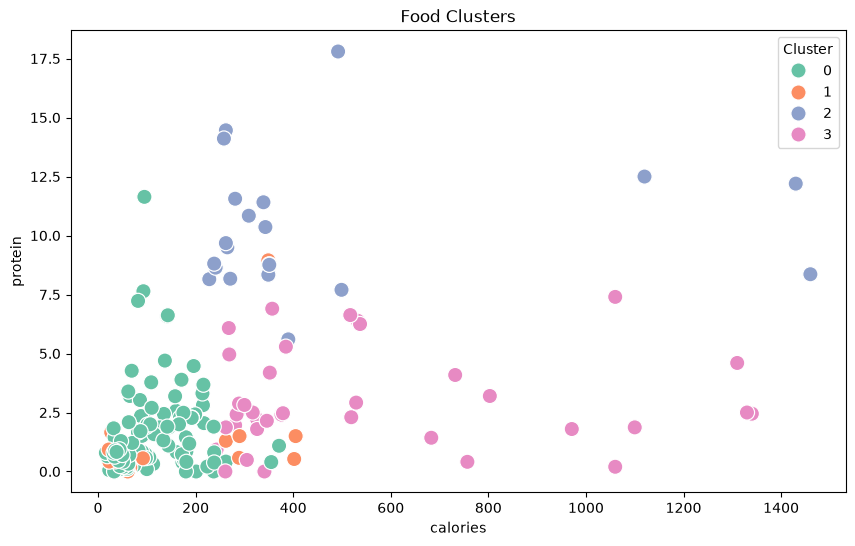

In [21]:
# ==========================================
# Cluster Visualization
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="calories",
    y="protein",
    hue="Cluster",
    palette="Set2",
    s=120
)

plt.title("Food Clusters")

plt.show()

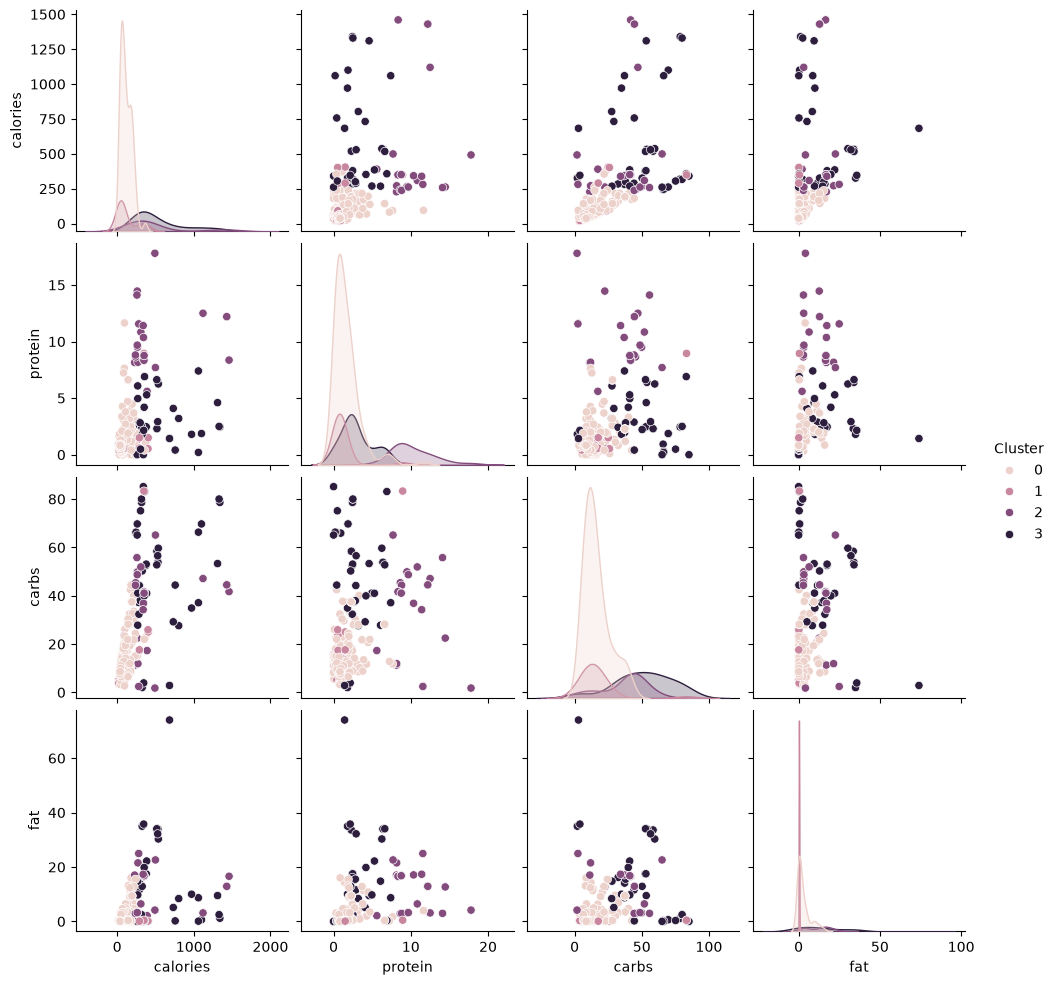

In [22]:
# ==========================================
# Pair Plot
# ==========================================

sns.pairplot(
    df,
    vars=["calories","protein","carbs","fat"],
    hue="Cluster"
)

plt.show()

In [ ]:
# ==========================================
# Save Clustered Dataset
# ==========================================

df.to_csv(
    "/Food_Nutrition_Clustered.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [24]:
# ==========================================
# Predict Cluster for New Food
# ==========================================

new_food = pd.DataFrame({

    "calories":[120],
    "protein":[8],
    "carbs":[15],
    "fat":[4],
    "iron":[1.2],
    "vitamin_c":[12]

})

new_scaled = scaler.transform(new_food)

prediction = kmeans.predict(new_scaled)

print("Predicted Cluster :", prediction[0])

Predicted Cluster : 0


In [25]:
# ==========================================
# Foods in Each Cluster
# ==========================================

for i in sorted(df["Cluster"].unique()):

    print("="*50)

    print(f"Cluster {i}")

    print("="*50)

    print(df[df["Cluster"]==i][["food_name","category"]].head(15))

    print()

Cluster 0
                          food_name                       category
0                    Apple, candied                         Apples
1                        Apple, raw                         Apples
3                      Crisp, apple                 Cakes and pies
4                      Apple, baked                         Apples
5                       Apple cider                    Apple juice
6                    Cobbler, apple                 Cakes and pies
10                Apple pie filling                         Apples
12        Apple salad with dressing  Other fruits and fruit salads
14             Fruit butters, apple                         Sweets
15                 Rose-apples, raw        Fruits and Fruit Juices
16  Carrots, raw, salad with apples   Coleslaw, non-lettuce salads
17                    Banana, baked                        Bananas
18                      Banana, raw                        Bananas
20                    Banana nectar                 